 # 1. Introduction

This project uses a publicly available dataset of residential property sales from King County, USA, covering transactions between May 2014 and May 2015. The dataset includes detailed information on property characteristics such as living area size, number of bedrooms and bathrooms, construction year, structural quality (grade), and locational attributes including latitude, longitude, and zipcode. Housing markets are influenced by a combination of structural features and geographic factors, and this dataset provides an opportunity to examine how these observable characteristics relate to variation in property prices. The objective of this analysis is to develop and evaluate predictive models that estimate house prices based on these features. Specifically, the study formulates the task as a supervised regression problem, where the target variable is transaction price (log-transformed to address skewness), and compares linear and non-linear modelling approaches in terms of predictive performance and generalisation ability.


# 2.0 Data Preparation

### 2.1 Data Loading

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline


In [6]:
df = pd.read_csv("kc_house_data.csv")

print(df.shape)
print(df.columns)
df.head()

(21613, 21)
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### 2.2 Initial Cleaning

In [7]:
df = df.drop(columns=["id"])

### 2.3 Temporal Feature Engineering

In [8]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df = df.drop(columns=["date"])

### 2.4 Feature Type Correction

In [9]:
df["zipcode"] = df["zipcode"].astype("category")
df["floors"] = df["floors"].astype("category")

### 2.5 Verification of Data Types

In [10]:
print(df.dtypes)

price             float64
bedrooms            int64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors           category
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
zipcode          category
lat               float64
long              float64
sqft_living15       int64
sqft_lot15          int64
year                int32
month               int32
dtype: object


# 3.0 EDA

### 3.1 Data Overview and Initial Inspection

Before building predictive models, it is important to understand the structure and quality of the dataset. In this section, I examine the dataset dimensions, variable types, and potential missing values. I also review summary statistics to understand the scale and distribution of key numerical features. This step helps identify any necessary preprocessing steps and ensures the dataset is suitable for regression modelling.


In [11]:
df.info()
df.isna().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   price          21613 non-null  float64 
 1   bedrooms       21613 non-null  int64   
 2   bathrooms      21613 non-null  float64 
 3   sqft_living    21613 non-null  int64   
 4   sqft_lot       21613 non-null  int64   
 5   floors         21613 non-null  category
 6   waterfront     21613 non-null  int64   
 7   view           21613 non-null  int64   
 8   condition      21613 non-null  int64   
 9   grade          21613 non-null  int64   
 10  sqft_above     21613 non-null  int64   
 11  sqft_basement  21613 non-null  int64   
 12  yr_built       21613 non-null  int64   
 13  yr_renovated   21613 non-null  int64   
 14  zipcode        21613 non-null  category
 15  lat            21613 non-null  float64 
 16  long           21613 non-null  float64 
 17  sqft_living15  21613 non-null  int64   
 1

,price,bedrooms,bathrooms,sqft_living,sqft_lot,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,year,month
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,47.560053,-122.213896,1986.552492,12768.455652,2014.322954,6.574423
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,0.138564,0.140828,685.391304,27304.179631,0.467616,3.115308
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.155900,-122.519000,399.000000,651.000000,2014.000000,1.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,47.471000,-122.328000,1490.000000,5100.000000,2014.000000,4.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.571800,-122.230000,1840.000000,7620.000000,2014.000000,6.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,47.678000,-122.125000,2360.000000,10083.000000,2015.000000,9.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000,2015.000000,12.000000


### 3.2 Data visualisation

The price distribution is highly right-skewed. Most houses are priced below 1 million, while only a small number of houses have very high prices. This long tail suggests the presence of outliers. Because such skewness can negatively affect regression models, we explore whether a log transformation may improve distributional symmetry.

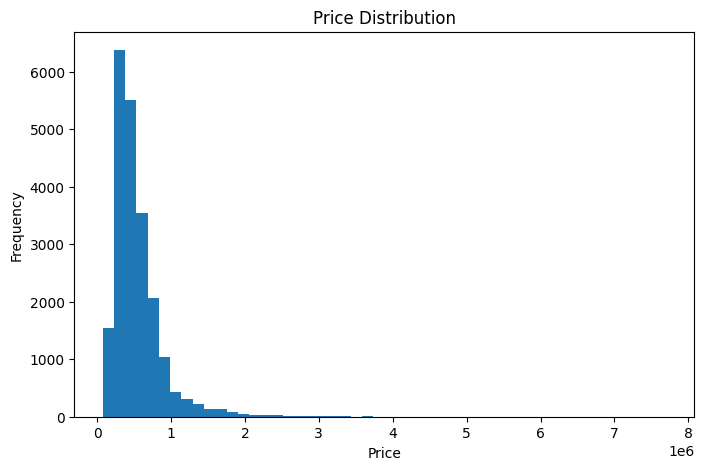

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The plot shows a strong positive relationship between living area and price. Larger houses tend to have higher prices. However, the points become more spread out for larger properties, suggesting increasing variance. There are also a few extreme values for very large houses. This indicates that the relationship may not be purely linear and that more flexible models may perform better than simple linear regression.

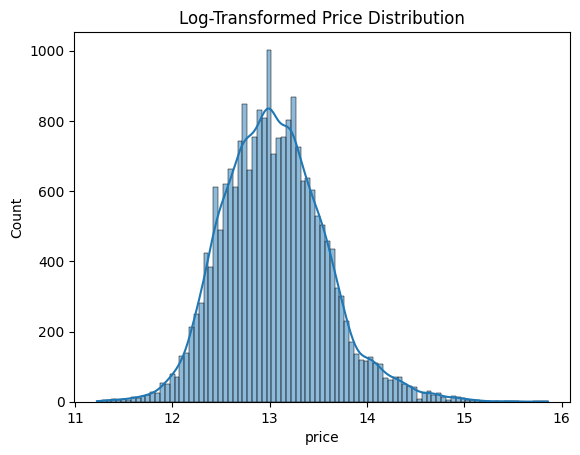

In [13]:
sns.histplot(np.log1p(df["price"]), kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

After applying the log transformation, the distribution becomes substantially more symmetric and closer to normal. Therefore, subsequent modelling will use the log-transformed target variable.

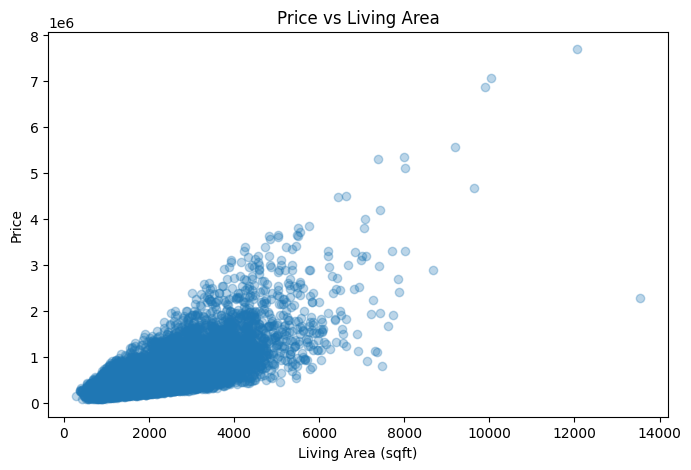

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df["sqft_living"], df["price"], alpha=0.3)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs Living Area")
plt.show()

The correlation heatmap provides an overview of the linear relationships between numerical variables in the dataset. As expected, sqft_living, grade, and bathrooms show relatively strong positive correlations with house price, suggesting that larger and higher-quality properties tend to be more expensive.

We also observe high correlations among certain features, such as sqft_living and sqft_above, which indicates potential multicollinearity. This may affect linear regression models but is less problematic for tree-based models such as Random Forest.

Overall, the heatmap helps identify key predictive variables and highlights structural relationships within the dataset.

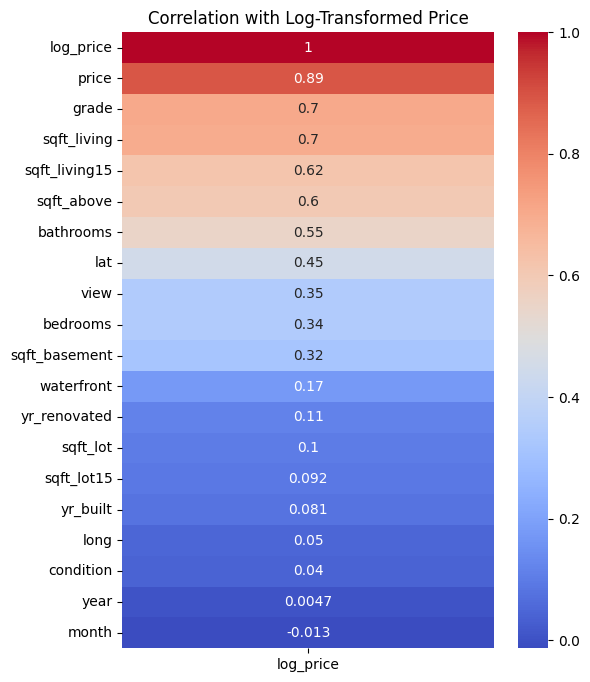

In [18]:
df_tmp = df.copy()
df_tmp["log_price"] = np.log1p(df_tmp["price"])

corr = df_tmp.corr(numeric_only=True)
log_corr = corr[["log_price"]].sort_values(by="log_price", ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(log_corr, annot=True, cmap="coolwarm")
plt.title("Correlation with Log-Transformed Price")
plt.show()


## 4.0 Modelling

In [22]:
# Target and features
y = np.log1p(df["price"])
X = df.drop(columns=["price", "log_price"], errors="ignore")

# Stratified split based on price bins
bins = pd.qcut(df["price"], q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=bins
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Preprocessing
cat_cols = []
for c in ["zipcode", "floors"]:
    if c in X.columns:
        cat_cols.append(c)

num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

Train shape: (17290, 20)
Test shape: (4323, 20)


In [23]:
dummy_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

dummy_rmse = rmse(y_test, dummy_pred)
print(f"Dummy RMSE (log scale): {dummy_rmse:.4f}")

Dummy RMSE (log scale): 0.5292


In [24]:
lin_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

lin_rmse = rmse(y_test, lin_pred)
print(f"Linear Regression RMSE (log scale): {lin_rmse:.4f}")

Linear Regression RMSE (log scale): 0.2203


In [60]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = rmse(y_test, rf_pred)
print(f"Random Forest RMSE (log scale): {rf_rmse:.4f}")

# Back-transform to original price scale
y_test_price = np.expm1(y_test)
rf_pred_price = np.expm1(rf_pred)

rmse_price = np.sqrt(mean_squared_error(y_test_price, rf_pred_price))
print(f"Random Forest RMSE (price scale): {rmse_price:,.0f}")

Random Forest RMSE (log scale): 0.1717
Random Forest RMSE (price scale): 126,633


In [62]:
cv_rmse = -cross_val_score(
    rf_model,
    X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
).mean()

print(f"Random Forest 5-fold CV RMSE (log scale): {cv_rmse:.4f}")

Random Forest 5-fold CV RMSE (log scale): 0.1779


In [ ]:
for depth in [5, 10, 20, None]:
    rf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv_scores = -cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    )

    print(f"Depth {depth} → CV RMSE: {cv_scores.mean():.4f}")


Depth 5 → CV RMSE: 0.2434
Depth 10 → CV RMSE: 0.1873


In [82]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)


Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 0.17858775123931112


In [83]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Optimized RF RMSE:", rmse_best)


Optimized RF RMSE: 0.1762400292970338


In [84]:
feature_importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importances.head(10))


grade            0.346832
lat              0.297142
sqft_living      0.179641
long             0.044119
sqft_living15    0.024791
yr_built         0.020546
sqft_lot         0.014725
sqft_above       0.013287
sqft_lot15       0.012878
zipcode          0.010175
dtype: float64


In [85]:
train_pred = best_rf.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
print("Train RMSE:", train_rmse)
print("Test RMSE:", rmse_best)


Train RMSE: 0.08470823581674577
Test RMSE: 0.1762400292970338


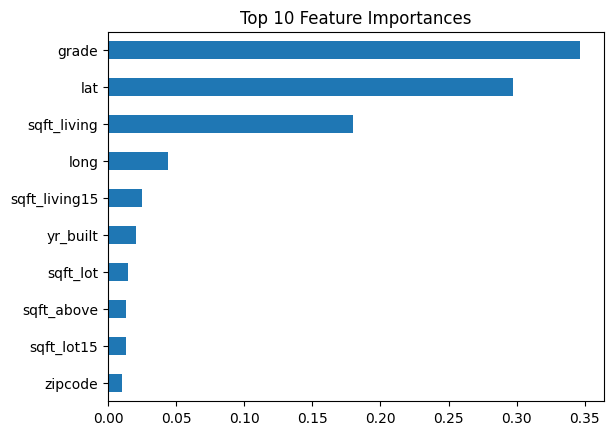

In [86]:
feature_importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

In [26]:
1+1


2